In [1]:
## imports

In [2]:
import os
print("Current working directory:", os.getcwd())
print("Files here:", os.listdir())

Current working directory: C:\Users\bhaga\OneDrive\Desktop\MTech MFAI
Files here: ['.ipynb_checkpoints', 'coVariance.ipynb', 'covariance_heatmap.png', 'deviations_bar.png', 'EigenValues.ipynb', 'eigenvalues_bar.png', 'EigenVectors.ipynb', 'scatter_pairs.png', 'scree_plot.png']


In [3]:
import numpy as np
import import_ipynb
import EigenValues as ev
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
## Computing Eigenvectors


In [5]:
def calculate_eigenvectors(matrix):

    print("\n")
    print("EIGENVECTORS")

    eigenvalues, eigenvectors = np.linalg.eig(matrix)

    for i in range(len(eigenvalues)):

        print(f"\nEigenvalue λ{i + 1} = {eigenvalues[i]:.3f}")

        print("Eigenvector:")

        for value in eigenvectors[:, i]:
            print(f"{value:.3f}")

    return eigenvalues, eigenvectors

In [6]:
def verify_eigenvectors(matrix, eigenvalues, eigenvectors):

    print("\n")
    print("VERIFICATION")

    print("\nEigenvalue equation:")
    print("A v = λ v")

    for i in range(len(eigenvalues)):

        v = eigenvectors[:, i]
        lam = eigenvalues[i]

        matrixv = matrix @ v
        lambda_v = lam * v

        print(f"\nFor λ{i + 1} = {lam:.3f}")

        print("\nEigenvector v:")
        for value in v:
            print(f"{value:.3f}")

        print("\nA × v:")
        for value in matrixv:
            print(f"{value:.3f}")

        print("\nλ × v:")
        for value in lambda_v:
            print(f"{value:.3f}")

        if np.allclose(matrixv, lambda_v):
            print("\nA × v = λ × v")
            print("Verified")
        else:
            print("\nA × v ≠ λ × v")
            print("Not Verified")

In [7]:
## Verifying the Eigenvalue Equation


In [8]:
if __name__ == "__main__":
    
    A = ev.input_matrix()
    ev.print_matrix(A, "Original Matrix A")
    
    trace, determinant = ev.matrix_information(A)
    I = ev.display_identity_matrix(A)
    
    ev.show_characteristic_equation(A)
    eigenvalues, eigenvectors = calculate_eigenvectors(A)
    
    verify_eigenvectors(A, eigenvalues, eigenvectors)

Enter order of matrix: 3

Enter 3 x 3 matrix elements row-wise:
Row 1: 9.067     -10.077      -0.727
Row 2: -10.077     159.125     123.054
Row 3: -0.727     123.054     684.696

Original Matrix A:
     9.067   -10.077    -0.727
   -10.077   159.125   123.054
    -0.727   123.054   684.696

Order of matrix  : 3
Trace of matrix  : 852.89
Determinant      : 782765.73

Identity Matrix I:
         1         0         0
         0         1         0
         0         0         1


CHARACTERISTIC EQUATION
(9.067 - λ)   -10.077   -0.727
-10.077   (159.125 - λ)   123.054
-0.727   123.054   (684.696 - λ)


EIGENVECTORS

Eigenvalue λ1 = 8.296
Eigenvector:
-0.997
-0.077
0.013

Eigenvalue λ2 = 132.500
Eigenvector:
-0.078
0.973
-0.217

Eigenvalue λ3 = 712.092
Eigenvector:
-0.004
0.217
0.976


VERIFICATION

Eigenvalue equation:
A v = λ v

For λ1 = 8.296

Eigenvector v:
-0.997
-0.077
0.013

A × v:
-8.271
-0.640
0.108

λ × v:
-8.271
-0.640
0.108

A × v = λ × v
Verified

For λ2 = 132.500

Eigenvector

In [9]:
## Eigenvectors as Direction Arrows (3D)


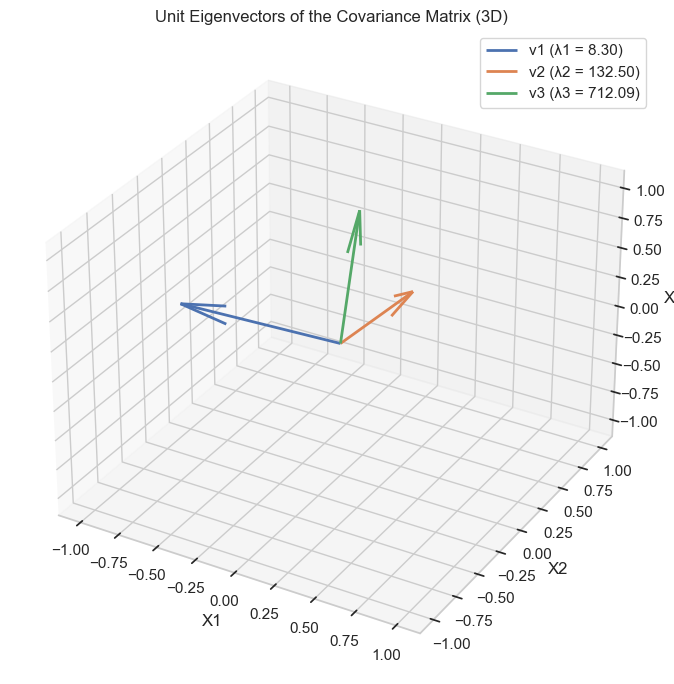

In [10]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (enables 3D projection)

feature_names = ["X1", "X2", "X3"]
colors = ["#4C72B0", "#DD8452", "#55A868"]

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="3d")

for i in range(eigenvectors.shape[1]):
    v = eigenvectors[:, i].real
    lam = eigenvalues[i].real
    ax.quiver(0, 0, 0, v[0], v[1], v[2], color=colors[i % len(colors)], linewidth=2,
              label=f"v{i+1} (λ{i+1} = {lam:.2f})")

lim = 1.1
ax.set_xlim([-lim, lim]); ax.set_ylim([-lim, lim]); ax.set_zlim([-lim, lim])
ax.set_xlabel(feature_names[0]); ax.set_ylabel(feature_names[1]); ax.set_zlabel(feature_names[2])
ax.set_title("Unit Eigenvectors of the Covariance Matrix (3D)")
ax.legend()
plt.tight_layout()
plt.savefig("eigenvectors_3d.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
## Diagonalization Check ($A$ vs. $Q\Lambda Q^{T}$)


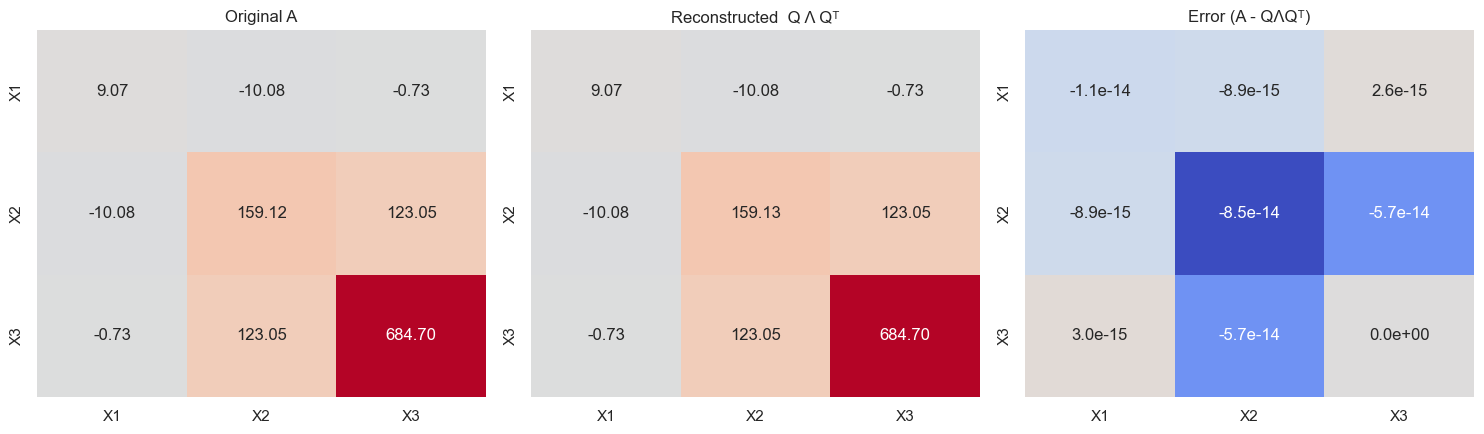

Max absolute reconstruction error: 8.53e-14


In [12]:
Q = eigenvectors.real
Lambda = np.diag(eigenvalues.real)
A_rebuilt = Q @ Lambda @ Q.T

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sns.heatmap(A, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            xticklabels=feature_names, yticklabels=feature_names, ax=axes[0], cbar=False)
axes[0].set_title("Original A")

sns.heatmap(A_rebuilt, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            xticklabels=feature_names, yticklabels=feature_names, ax=axes[1], cbar=False)
axes[1].set_title("Reconstructed  Q Λ Qᵀ")

error = A - A_rebuilt
sns.heatmap(error, annot=True, fmt=".1e", cmap="coolwarm", center=0,
            xticklabels=feature_names, yticklabels=feature_names, ax=axes[2], cbar=False)
axes[2].set_title("Error (A - QΛQᵀ)")

plt.tight_layout()
plt.savefig("diagonalization_check.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Max absolute reconstruction error: {np.max(np.abs(error)):.2e}")

In [13]:
## $\|Av - \lambda v\|$ Residuals


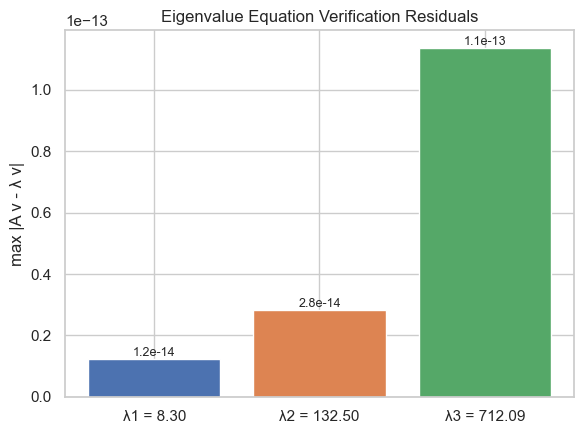

In [14]:
residuals = []
for i in range(len(eigenvalues)):
    v = eigenvectors[:, i]
    lam = eigenvalues[i]
    residuals.append(np.max(np.abs(A @ v - lam * v)))

labels = [f"λ{i+1} = {eigenvalues[i].real:.2f}" for i in range(len(eigenvalues))]

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(labels, residuals, color=["#4C72B0", "#DD8452", "#55A868"])
for bar, val in zip(bars, residuals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.1e}",
            ha="center", va="bottom", fontsize=9)

ax.set_ylabel("max |A v - λ v|")
ax.set_title("Eigenvalue Equation Verification Residuals")
plt.tight_layout()
plt.savefig("verification_residuals.png", dpi=150, bbox_inches="tight")
plt.show()